In [6]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import arviz as az

# ============================================================
# Stand-alone script: Student-t ENSO/IOD experiments -> tables
#   - Loads Student-t mean-shift idata for selected basins
#   - Runs ENSO/IOD experiments like the map script
#   - Computes basin-mean Δμ and 94% HDI
#   - Saves long and wide CSV tables
# ============================================================

# ----------------------------
# User settings
# ----------------------------
BASINS = [
    "arabian_gulf",
    "red_sea",
    "gulf_oman",
    "gulf_aden",
]

EXPERIMENTS = [
    {"name": "El Niño (+1,0)",                 "N": +1.0, "D":  0.0},
    {"name": "La Niña (-1,0)",                 "N": -1.0, "D":  0.0},
    {"name": "pIOD (0,+1)",                    "N":  0.0, "D": +1.0},
    {"name": "nIOD (0,-1)",                    "N":  0.0, "D": -1.0},

    {"name": "La Niña + pIOD (-1,+1)",        "N": -1.0, "D": +1.0},
    {"name": "La Niña + nIOD (-1,-1)",        "N": -1.0, "D": -1.0},

    {"name": "Strong La Niña (-2,0)",         "N": -2.0, "D":  0.0},
    {"name": "Super La Niña (-2.5,0)",        "N": -2.5, "D":  0.0},
    {"name": "Strong La Niña + nIOD (-2,-1)", "N": -2.0, "D": -1.0},

    {"name": "Strong El Niño (+2,0)",         "N": +2.0, "D":  0.0},
    {"name": "El Niño + pIOD (+1,+1)",        "N": +1.0, "D": +1.0},
    {"name": "El Niño + nIOD (+1,-1)",        "N": +1.0, "D": -1.0},
]

# Update this if your idata files live elsewhere
IDATA_TEMPLATE = "../data/sst/studentt_mean_{basin}_roni_dmi_idata.nc"

OUT_DIR = "../data/sst/studentt_experiment_tables"
os.makedirs(OUT_DIR, exist_ok=True)

HDI_PROB = 0.94


# ----------------------------
# Helpers
# ----------------------------
def _stack_draws(da):
    """
    Convert posterior variable with dims (chain, draw, space)
    into dims (sample, space).
    """
    if "chain" in da.dims and "draw" in da.dims:
        return da.stack(sample=("chain", "draw"))
    if "sample" in da.dims:
        return da
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")


def delta_mu_draws(idata, N_val, D_val):
    """
    Split-ENSO Student-t mean-shift model:

        Δμ = bNp_s*N_pos + bNn_s*N_neg + bD_s*D
           + bNpD_s*(N_pos*D) + bNnD_s*(N_neg*D)

    where:
        N_pos = max(N, 0)
        N_neg = min(N, 0)
    """
    post = idata.posterior

    bNp_s  = _stack_draws(post["bNp_s"])
    bNn_s  = _stack_draws(post["bNn_s"])
    bD_s   = _stack_draws(post["bD_s"])
    bNpD_s = _stack_draws(post["bNpD_s"])
    bNnD_s = _stack_draws(post["bNnD_s"])

    N_pos = max(N_val, 0.0)
    N_neg = min(N_val, 0.0)

    dmu = (
        bNp_s * N_pos
        + bNn_s * N_neg
        + bD_s * D_val
        + bNpD_s * (N_pos * D_val)
        + bNnD_s * (N_neg * D_val)
    )

    return dmu


def basin_mean_and_hdi(field_draws, hdi_prob=0.94):
    """
    Collapse (sample, space) -> basin-mean posterior draws (sample,)
    then summarize with posterior mean and HDI.
    """
    basin_mean_draws = field_draws.mean(dim="space")
    mean_val = float(basin_mean_draws.mean().values)
    lo, hi = az.hdi(basin_mean_draws.values, hdi_prob=hdi_prob)
    return mean_val, float(lo), float(hi)


def build_experiment_table(idata, basin_name, experiments, hdi_prob=0.94):
    """
    Build a long-form experiment table for one basin.
    """
    rows = []

    for exp in experiments:
        dmu_draws = delta_mu_draws(idata, exp["N"], exp["D"])
        mean_val, lo, hi = basin_mean_and_hdi(dmu_draws, hdi_prob=hdi_prob)

        rows.append({
            "basin": basin_name,
            "experiment": exp["name"],
            "N": exp["N"],
            "D": exp["D"],
            "mean_dmu": mean_val,
            "hdi_low": lo,
            "hdi_high": hi,
        })

    return pd.DataFrame(rows)


def format_result(mean_val, lo, hi, decimals=3):
    return f"{mean_val:+.{decimals}f} [{lo:+.{decimals}f}, {hi:+.{decimals}f}]"


# ----------------------------
# Main
# ----------------------------
def main():
    all_tables = []

    for basin in BASINS:
        idata_path = IDATA_TEMPLATE.format(basin=basin)

        if not os.path.exists(idata_path):
            print(f"⚠️ Missing idata file, skipping basin: {basin}")
            print(f"   Expected: {idata_path}")
            continue

        print(f"Loading: {idata_path}")
        idata = az.from_netcdf(idata_path)

        # sanity check
        required_vars = {"bNp_s", "bNn_s", "bD_s", "bNpD_s", "bNnD_s"}
        missing = required_vars - set(idata.posterior.data_vars)
        if missing:
            print(f"⚠️ Missing posterior vars for {basin}: {sorted(missing)}")
            continue

        basin_df = build_experiment_table(
            idata=idata,
            basin_name=basin,
            experiments=EXPERIMENTS,
            hdi_prob=HDI_PROB,
        )

        all_tables.append(basin_df)

    if not all_tables:
        raise FileNotFoundError("No valid idata files were found for the requested basins.")

    final_table = pd.concat(all_tables, ignore_index=True)

    # formatted string column for easier viewing / paper tables
    final_table["result"] = final_table.apply(
        lambda r: format_result(r["mean_dmu"], r["hdi_low"], r["hdi_high"]),
        axis=1
    )

    # save long table
    long_out = os.path.join(OUT_DIR, "studentt_mean_shift_experiment_table_long.csv")
    final_table.to_csv(long_out, index=False)
    print(f"✅ Saved long table: {long_out}")

    # wide/pivot table with formatted strings
    wide_table = final_table.pivot(
        index="experiment",
        columns="basin",
        values="result"
    )

    wide_out = os.path.join(OUT_DIR, "studentt_mean_shift_experiment_table_wide.csv")
    wide_table.to_csv(wide_out)
    print(f"✅ Saved wide table: {wide_out}")

    # also save a numeric wide version if you want to work with the values later
    mean_wide = final_table.pivot(index="experiment", columns="basin", values="mean_dmu")
    lo_wide   = final_table.pivot(index="experiment", columns="basin", values="hdi_low")
    hi_wide   = final_table.pivot(index="experiment", columns="basin", values="hdi_high")

    mean_out = os.path.join(OUT_DIR, "studentt_mean_shift_mean_only.csv")
    lo_out   = os.path.join(OUT_DIR, "studentt_mean_shift_hdi_low_only.csv")
    hi_out   = os.path.join(OUT_DIR, "studentt_mean_shift_hdi_high_only.csv")

    mean_wide.to_csv(mean_out)
    lo_wide.to_csv(lo_out)
    hi_wide.to_csv(hi_out)

    print(f"✅ Saved mean-only table: {mean_out}")
    print(f"✅ Saved HDI-low table:  {lo_out}")
    print(f"✅ Saved HDI-high table: {hi_out}")

    # print preview
    print("\n=== Long table preview ===")
    print(final_table.to_string(index=False))

    print("\n=== Wide formatted table ===")
    print(wide_table.to_string())


if __name__ == "__main__":
    main()

Loading: ../data/sst/studentt_mean_arabian_gulf_roni_dmi_idata.nc
Loading: ../data/sst/studentt_mean_red_sea_roni_dmi_idata.nc
Loading: ../data/sst/studentt_mean_gulf_oman_roni_dmi_idata.nc
Loading: ../data/sst/studentt_mean_gulf_aden_roni_dmi_idata.nc
✅ Saved long table: ../data/sst/studentt_experiment_tables/studentt_mean_shift_experiment_table_long.csv
✅ Saved wide table: ../data/sst/studentt_experiment_tables/studentt_mean_shift_experiment_table_wide.csv
✅ Saved mean-only table: ../data/sst/studentt_experiment_tables/studentt_mean_shift_mean_only.csv
✅ Saved HDI-low table:  ../data/sst/studentt_experiment_tables/studentt_mean_shift_hdi_low_only.csv
✅ Saved HDI-high table: ../data/sst/studentt_experiment_tables/studentt_mean_shift_hdi_high_only.csv

=== Long table preview ===
       basin                    experiment    N    D  mean_dmu   hdi_low  hdi_high                  result
arabian_gulf                El Niño (+1,0)  1.0  0.0 -0.121657 -0.132012 -0.110906 -0.122 [-0.132, -0.1

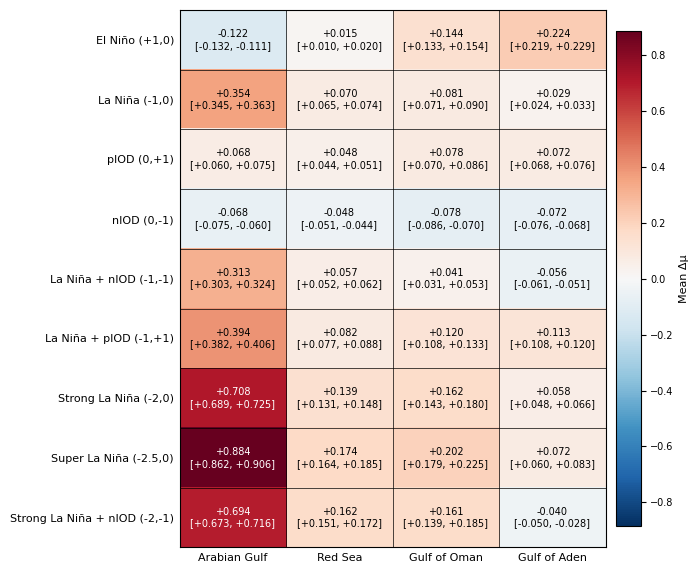

✅ Saved PNG: ../figures/studentt_mean_shift_heatmaps/studentt_mean_shift_experiment_heatmap.png
✅ Saved PDF: ../figures/studentt_mean_shift_heatmaps/studentt_mean_shift_experiment_heatmap.pdf


In [8]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# Stand-alone script: manuscript-ready heatmap from saved
# Student-t experiment CSV
#   - Reads the long CSV made by the previous script
#   - Makes a heatmap with:
#       color = mean_dmu
#       text  = mean_dmu and HDI
#   - Saves BOTH PNG and PDF
# ============================================================

# ----------------------------
# User settings
# ----------------------------
CSV_PATH = "../data/sst/studentt_experiment_tables/studentt_mean_shift_experiment_table_long.csv"
OUT_DIR = "../figures/studentt_mean_shift_heatmaps"
OUT_NAME_PNG = "studentt_mean_shift_experiment_heatmap.png"
OUT_NAME_PDF = "studentt_mean_shift_experiment_heatmap.pdf"
os.makedirs(OUT_DIR, exist_ok=True)

BASIN_ORDER = [
    "arabian_gulf",
    "red_sea",
    "gulf_oman",
    "gulf_aden",
]

EXPERIMENT_ORDER = [
    "El Niño (+1,0)",
    "La Niña (-1,0)",
    "pIOD (0,+1)",
    "nIOD (0,-1)",
    "La Niña + nIOD (-1,-1)",
    "La Niña + pIOD (-1,+1)",
    "Strong La Niña (-2,0)",
    "Super La Niña (-2.5,0)",
    "Strong La Niña + nIOD (-2,-1)",
]

VALUE_COL = "mean_dmu"
LOW_COL = "hdi_low"
HIGH_COL = "hdi_high"

CBAR_LABEL = "Mean Δμ"

BASIN_LABELS = {
    "arabian_gulf": "Arabian Gulf",
    "red_sea": "Red Sea",
    "gulf_oman": "Gulf of Oman",
    "gulf_aden": "Gulf of Aden",
}

# ============================================================
# Figure style (manuscript-friendly)
# ============================================================
ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.transparent": False,
    "path.simplify": False,
}


# ----------------------------
# Load table
# ----------------------------
df = pd.read_csv(CSV_PATH)

required_cols = {"basin", "experiment", VALUE_COL, LOW_COL, HIGH_COL}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

# keep only requested basins/order
df = df[df["basin"].isin(BASIN_ORDER)].copy()

# optional sanity checks
missing_basins = sorted(set(BASIN_ORDER) - set(df["basin"].unique()))
missing_experiments = sorted(set(EXPERIMENT_ORDER) - set(df["experiment"].unique()))

if missing_basins:
    print(f"⚠️ Missing basins in CSV: {missing_basins}")
if missing_experiments:
    print(f"⚠️ Missing experiments in CSV: {missing_experiments}")

# ----------------------------
# Pivot to matrices
# ----------------------------
mean_mat = (
    df.pivot(index="experiment", columns="basin", values=VALUE_COL)
      .reindex(index=EXPERIMENT_ORDER, columns=BASIN_ORDER)
)

lo_mat = (
    df.pivot(index="experiment", columns="basin", values=LOW_COL)
      .reindex(index=EXPERIMENT_ORDER, columns=BASIN_ORDER)
)

hi_mat = (
    df.pivot(index="experiment", columns="basin", values=HIGH_COL)
      .reindex(index=EXPERIMENT_ORDER, columns=BASIN_ORDER)
)

data = mean_mat.values.astype(float)

# symmetric diverging scale around zero
vmax = np.nanmax(np.abs(data))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# ----------------------------
# Plot
# ----------------------------
with mpl.rc_context(ERL_RC):
    fig, ax = plt.subplots(figsize=(7.1, 5.8))

    im = ax.imshow(data, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_xticks(np.arange(len(BASIN_ORDER)))
    ax.set_xticklabels(
        [BASIN_LABELS.get(b, b.replace("_", " ").title()) for b in BASIN_ORDER],
        fontsize=8
    )

    ax.set_yticks(np.arange(len(EXPERIMENT_ORDER)))
    ax.set_yticklabels(EXPERIMENT_ORDER, fontsize=8)

    # no title for manuscript figure; caption will explain details

    # draw cell borders
    ax.set_xticks(np.arange(-0.5, len(BASIN_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(EXPERIMENT_ORDER), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # clean major tick appearance
    ax.tick_params(axis="x", which="major", length=0, pad=4)
    ax.tick_params(axis="y", which="major", length=0, pad=4)

    # annotate cells
    for i in range(len(EXPERIMENT_ORDER)):
        for j in range(len(BASIN_ORDER)):
            val = mean_mat.iloc[i, j]
            lo = lo_mat.iloc[i, j]
            hi = hi_mat.iloc[i, j]

            if pd.isna(val):
                txt = "NA"
                color = "black"
            else:
                txt = f"{val:+.3f}\n[{lo:+.3f}, {hi:+.3f}]"
                frac = abs(val) / vmax if vmax > 0 else 0
                color = "white" if frac > 0.45 else "black"

            ax.text(
                j, i, txt,
                ha="center", va="center",
                fontsize=7,
                color=color
            )

    cbar = fig.colorbar(im, ax=ax, shrink=0.92, pad=0.02)
    cbar.set_label(CBAR_LABEL, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.tight_layout()

    out_path_png = os.path.join(OUT_DIR, OUT_NAME_PNG)
    out_path_pdf = os.path.join(OUT_DIR, OUT_NAME_PDF)

    fig.savefig(out_path_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(out_path_pdf, dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()

print(f"✅ Saved PNG: {out_path_png}")
print(f"✅ Saved PDF: {out_path_pdf}")